## Daily heat exposure analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Summary statistics
 - number of pregnancies by country (N)
 - proportion (% days) of heat days by country (Q1, Q3, median)
 - number of heatwave events by country (Q1, Q3, median)
 - average duration of heatwave events by country (Q1, Q3, median)

Proportions of heat days for each participant using different `heat day` definitions and different sources of temperature data.


ID | Definition | Threshold |
---|------------|-----------|
HD_P75| moderate | > $75 ^th $ percentile
HD_P90| high | > $90 ^th $ percentile
HD_P95| extreme | > $95 ^th $ percentile

In [13]:
out_dict = dict()
for source in ["ERA-5", "MERRA-2"]:
    out_df = pd.DataFrame()
    temp = pd.DataFrame()
    for level in ["facility", "village", "centroid"]:
        # proportion of heat days by participant, using ERA-5 data
        data = (
            pd.read_csv(
                f"../data/processed/heat_days/{level}-level/{source}_heat_days.csv"
            )
            # format values to pct
            .apply(lambda x: 100 * x if x.dtype == np.float64 else x)
        )
        for country in ["Total", "Gambia", "Kenya", "Mozambique"]:
            subset = (
                data.copy() if country == "Total" else data[data["Country"] == country]
            )
            # compute IQR for each heat definition
            for hd in ["hd_p75", "hd_p90", "hd_p95"]:
                Q1 = subset[hd].quantile(0.25)
                Q3 = subset[hd].quantile(0.75)
                median = subset[hd].median()
                temp.loc[hd, country] = f"{median:.2f} ({Q1:.2f} - {Q3:.2f})"
        temp["level"] = level

        out_df = pd.concat([out_df, temp])
    out_df["Heat exposure metric"] = (
        "ERA-5 T2MWET" if source == "Dewpoint" else f"{source} T2M"
    )
    out_dict[source] = out_df

In [ ]:
anc_data = pd.read_csv("../data/interim/anc_daily_attendance.csv")
anc_data = (
    anc_data.groupby(["Country", "f2a_participant_id"]).size().groupby("Country").size()
)
# summarise total pregnancies by country as N
anc_data.loc["Total"] = anc_data.sum()
anc_data = pd.DataFrame(anc_data.to_dict(), index=["pregnancies"]).map(
    lambda x: f"{x:,}"
)

# using just village-centroid data since there are no differences with other levels
# to-do check this!!!
out_dict = {k: df[df["level"] == "village"] for k, df in out_dict.items()}

# put all data into the same table for reporting summary stats
final_df = pd.concat(
    [
        anc_data,
        out_dict["ERA-5"],
        out_dict["MERRA-2"],
    ]
).drop(columns="level")

# final_df.to_csv("../reports/longterm-heat-exposure-summary.csv")

,Gambia,Kenya,Mozambique,Total,Heat exposure metric
pregnancies,"1,325","3,309","2,053","6,687",NaN
hd_p75,26.09 (23.02 - 30.52),23.48 (20.45 - 30.05),22.97 (21.43 - 25.55),23.99 (21.02 - 28.43),ERA-5 T2M
hd_p90,8.75 (7.32 - 14.81),8.66 (6.33 - 11.86),9.78 (9.19 - 11.51),9.41 (7.48 - 11.83),ERA-5 T2M
hd_p95,3.92 (2.52 - 7.87),4.37 (1.90 - 5.60),4.49 (4.20 - 7.08),4.46 (2.52 - 5.88),ERA-5 T2M
hd_p75,25.14 (23.35 - 27.17),25.14 (21.01 - 32.47),25.07 (22.99 - 27.35),25.13 (22.49 - 28.77),MERRA-2 T2M
hd_p90,9.88 (8.70 - 10.86),10.14 (3.92 - 17.00),10.36 (9.65 - 12.43),10.16 (8.51 - 12.57),MERRA-2 T2M
hd_p95,4.59 (3.46 - 5.73),3.37 (0.79 - 9.80),6.47 (6.02 - 7.01),5.44 (3.12 - 6.92),MERRA-2 T2M


Number of heatwave events and average duration (days) for each participant using different `heatwave` definitions from different data sources.

ID | Heat day threshold | Consecutive heat days
---|--------------------|----------------------
HW_1a| > $75 ^th $ percentile | >= 2
HW_1b| > $75 ^th $ percentile | >= 3
HW_1c| > $75 ^th $ percentile | >= 4
HW_2a| > $90 ^th $ percentile | >= 2
HW_2b| > $90 ^th $ percentile | >= 3
HW_2c| > $90 ^th $ percentile | >= 4
HW_3a| > $95 ^th $ percentile | >= 2
HW_3b| > $95 ^th $ percentile | >= 3
HW_3c| > $95 ^th $ percentile | >= 4


In [15]:
# Heat wave events count
out_dict = dict()
for source in ["ERA-5", "MERRA-2"]:
    out_df = pd.DataFrame()
    temp = pd.DataFrame()
    for level in ["facility", "village", "centroid"]:
        # counts of heatwave events by participant, using ERA-5 data
        data = pd.read_csv(
            f"../data/processed/heat_waves/{level}-level/{source}_heat_waves.csv"
        )
        for country in ["Total", "Gambia", "Kenya", "Mozambique"]:
            subset = (
                data.copy() if country == "Total" else data[data["Country"] == country]
            )
            # compute IQR for each heat definition
            for i in range(1, 4):
                for alph in ["a", "b", "c"]:
                    # heat wave definition
                    hw = f"hw{i}{alph}_num"
                    Q1 = subset[hw].quantile(0.25)
                    Q3 = subset[hw].quantile(0.75)
                    median = subset[hw].median()
                    temp.loc[hw[:-4], country] = f"{median:.0f} ({Q1:.0f} - {Q3:.0f})"

        temp["level"] = level

        out_df = pd.concat([out_df, temp])

    out_df["Heat exposure metric"] = (
        "ERA-5 T2MWET" if source == "Dewpoint" else f"{source} T2M"
    )
    out_dict[source] = out_df

In [17]:
# using just village-centroid data since there are no differences with other levels
# to-do check this!!!
out_dict = {k: df[df["level"] == "village"] for k, df in out_dict.items()}
heatwave_counts = pd.concat(
    [
        out_dict["ERA-5"],
        out_dict["MERRA-2"],
    ]
).drop(columns="level")

In [18]:
# Heat wave events duration
out_dict = dict()
for source in ["ERA-5", "MERRA-2"]:
    out_df = pd.DataFrame()
    temp = pd.DataFrame()
    for level in ["facility", "village", "centroid"]:
        # duration of heatwaves by participant, using ERA-5 data
        data = pd.read_csv(
            f"../data/processed/heat_waves/{level}-level/{source}_heat_waves.csv"
        )
        for country in ["Total", "Gambia", "Kenya", "Mozambique"]:
            subset = (
                data.copy() if country == "Total" else data[data["Country"] == country]
            )
            # compute IQR for each heat definition
            for i in range(1, 4):
                for alph in ["a", "b", "c"]:
                    # heat wave definition
                    hw = f"hw{i}{alph}_avg"
                    Q1 = subset[hw].quantile(0.25)
                    Q3 = subset[hw].quantile(0.75)
                    median = subset[hw].median()
                    temp.loc[hw[:-4], country] = f"{median:.1f} ({Q1:.1f} - {Q3:.1f})"

        temp["level"] = level

        out_df = pd.concat([out_df, temp])

    out_df["Heat exposure metric"] = (
        "ERA-5 T2MWET" if source == "Dewpoint" else f"{source} T2M"
    )
    out_dict[source] = out_df

In [19]:
# using just village-centroid data since there are no differences with other levels
# to-do check this!!!
out_dict = {k: df[df["level"] == "village"] for k, df in out_dict.items()}
heatwave_duration = pd.concat(
    [
        out_dict["ERA-5"],
        out_dict["MERRA-2"],
    ]
).drop(columns="level")

In [ ]:
final_df = pd.merge(
    heatwave_counts,
    heatwave_duration,
    left_on=[heatwave_counts.index, "Heat exposure metric"],
    right_on=[heatwave_duration.index, "Heat exposure metric"],
    suffixes=("_count", "_duration"),
    validate="1:1",
)
# final_df.to_csv("../reports/shortterm-heatwave-exposure-summary.csv", index=False)

,key_0,Total_count,Gambia_count,Kenya_count,Mozambique_count,Heat exposure metric,Total_duration,Gambia_duration,Kenya_duration,Mozambique_duration
0,hw1a,15 (9 - 17),16 (13 - 18),8 (8 - 9),17 (16 - 18),ERA-5 T2M,5.8 (4.3 - 11.0),6.9 (4.5 - 8.3),12.3 (8.7 - 13.5),4.3 (4.2 - 5.2)
1,hw1b,11 (6 - 14),12 (10 - 13),6 (6 - 7),14 (11 - 15),ERA-5 T2M,7.5 (5.1 - 13.2),8.6 (5.5 - 10.6),16.8 (9.8 - 17.5),5.0 (4.5 - 6.3)
2,hw1c,8 (5 - 9),9 (8 - 10),5 (5 - 6),9 (8 - 9),ERA-5 T2M,9.2 (5.8 - 15.3),10.7 (6.1 - 12.3),18.5 (13.2 - 20.4),5.8 (5.5 - 7.5)
3,hw2a,8 (7 - 10),10 (5 - 15),7 (6 - 8),8 (7 - 11),ERA-5 T2M,4.1 (3.4 - 5.0),4.2 (4.0 - 4.4),5.0 (5.0 - 5.5),3.2 (3.2 - 3.6)
4,hw2b,5 (4 - 7),7 (4 - 8),6 (4 - 7),5 (4 - 6),ERA-5 T2M,5.1 (4.2 - 6.1),5.7 (5.0 - 6.2),5.8 (5.4 - 6.8),4.2 (4.2 - 4.2)
5,hw2c,3 (2 - 5),4 (3 - 5),5 (2 - 5),2 (2 - 3),ERA-5 T2M,6.0 (6.0 - 7.0),6.8 (5.0 - 8.4),6.8 (6.4 - 10.0),6.0 (5.3 - 6.0)
6,hw3a,4 (3 - 6),6 (3 - 7),3 (3 - 4),5 (4 - 7),ERA-5 T2M,3.8 (2.7 - 4.5),4.0 (4.0 - 4.5),4.7 (4.2 - 5.3),2.7 (2.4 - 3.0)
7,hw3b,2 (2 - 3),3 (2 - 3),2 (2 - 3),2 (1 - 3),ERA-5 T2M,5.0 (4.0 - 6.0),6.0 (5.0 - 7.0),6.0 (5.0 - 7.0),4.0 (3.7 - 4.0)
8,hw3c,2 (1 - 2),2 (2 - 2),2 (1 - 2),1 (1 - 2),ERA-5 T2M,6.0 (4.0 - 7.0),7.0 (5.0 - 9.0),6.0 (6.0 - 11.0),4.0 (4.0 - 4.0)
9,hw1a,11 (6 - 16),10 (8 - 11),6 (4 - 8),17 (15 - 18),MERRA-2 T2M,8.8 (5.1 - 20.0),9.7 (8.3 - 11.6),21.0 (15.1 - 27.6),4.9 (4.8 - 5.2)


### Analysing extreme heat days

- Health facility level analysis

In [2]:
# compare proportions of extreme heat days using ERA-5 and MERRA-2 datasets
era5 = pd.read_csv("../data/processed/heat_days/facility-level/ERA-5_heat_days.csv")
merra2 = pd.read_csv("../data/processed/heat_days/facility-level/MERRA-2_heat_days.csv")

In [8]:
def extreme_heat_data(level="facility"):
    out_df = pd.DataFrame()

    for source in ["ERA-5", "MERRA-2"]:
        data = pd.read_csv(
            f"../data/processed/heat_days/{level}-level/{source}_heat_days.csv"
        )
        # x-axis
        data["Exposure metric"] = (
            "ERA-5 T2MWET" if source == "Dewpoint" else f"{source} T2M"
        )
        # combine data sources
        out_df = pd.concat([out_df, data], ignore_index=True)
    return out_df

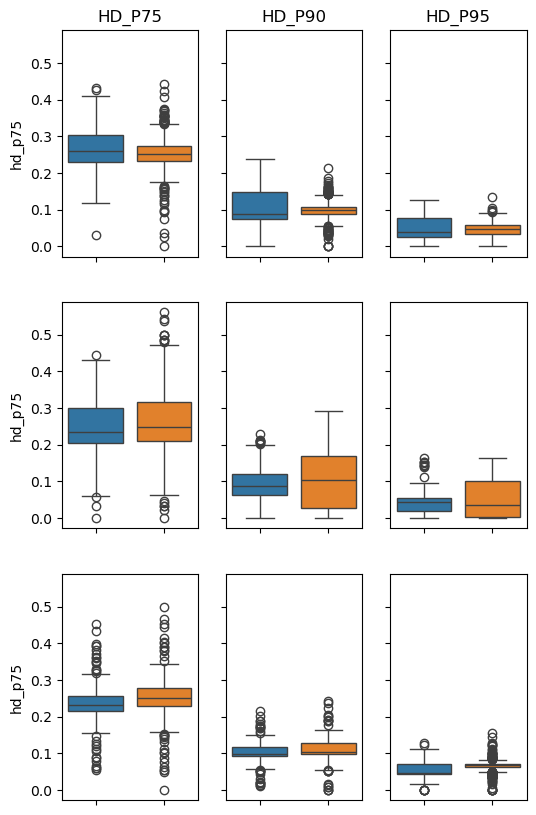

In [23]:
data = extreme_heat_data()
fig, axs = plt.subplots(3, 3, figsize=(6, 10), sharex=True, sharey=True)
for i, country in enumerate(["Gambia", "Kenya", "Mozambique"]):
    data_df = data[data["Country"] == country]

    for j, hd in enumerate(["hd_p75", "hd_p90", "hd_p95"]):
        sns.boxplot(
            data_df, x="Exposure metric", y=hd, hue="Exposure metric", ax=axs[i, j]
        )
        if i == 0:
            axs[i, j].set_title(hd.upper())
for ax in axs.flatten():
    ax.set_xlabel("")
    ax.set_xticklabels("")

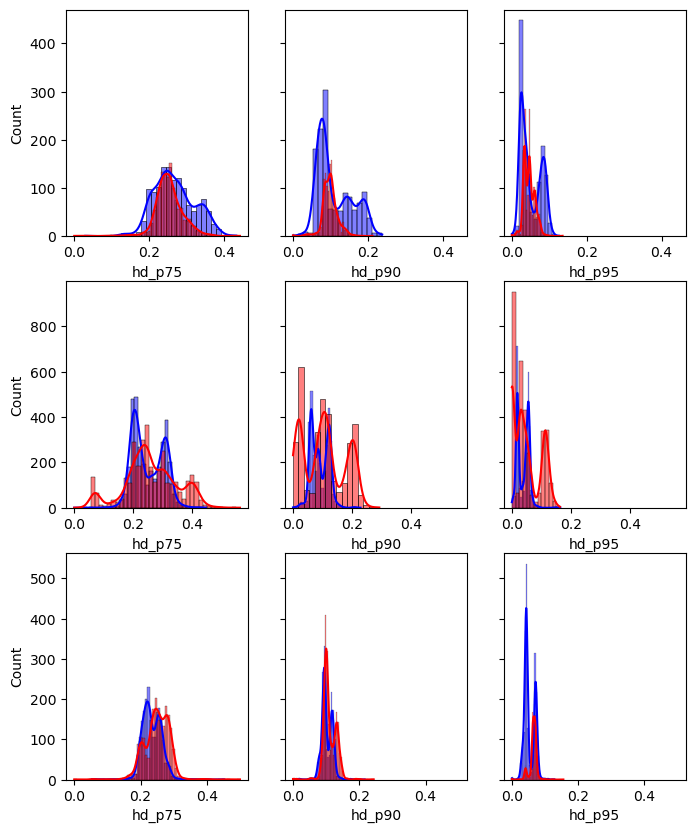

In [28]:
fig, axs = plt.subplots(3, 3, figsize=(8, 10), sharex="row", sharey="row")
for i, country in enumerate(["Gambia", "Kenya", "Mozambique"]):
    era5_df = era5[era5["Country"] == country]
    merra2_df = merra2[merra2["Country"] == country]

    for j, hd in enumerate(["hd_p75", "hd_p90", "hd_p95"]):
        sns.histplot(era5_df[hd], kde=True, color="blue", label="ERA-5", ax=axs[i, j])
        sns.histplot(
            merra2_df[hd], kde=True, color="red", label="MERRA-2", ax=axs[i, j]
        )

In [ ]:
sns.